In [ ]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.9 MB/s eta 0:00:00


In [ ]:
!unzip "Vehicle Detection.v2-dataset-with-truck-and-bus.yolov8.zip" -d vehicle_dataset

Archive:  Vehicle Detection.v2-dataset-with-truck-and-bus.yolov8.zip
 extracting: vehicle_dataset/README.dataset.txt  
 extracting: vehicle_dataset/README.roboflow.txt  
 extracting: vehicle_dataset/data.yaml  
   creating: vehicle_dataset/test/
   creating: vehicle_dataset/test/images/
 extracting: vehicle_dataset/test/images/image_1_1449_jpg.rf.cef2ca56f852e86e8a0487c11c01bcc7.jpg  
 extracting: vehicle_dataset/test/images/image_1_1751_jpg.rf.d33c55fa3cf0de702122d62225a1c7f4.jpg  
 extracting: vehicle_dataset/test/images/image_1_1781_jpg.rf.b63d466732a3bd3030c22952741ccc92.jpg  
 extracting: vehicle_dataset/test/images/image_1_1931_jpg.rf.8767744882c3d0da64b2988873cedacf.jpg  
 extracting: vehicle_dataset/test/images/image_1_2011_jpg.rf.5acc6c8eb048026989d28d8bd89f217e.jpg  
 extracting: vehicle_dataset/test/images/image_1_2023_jpg.rf.56b7d4ac2941b6a9dc005b9fe7657c44.jpg  
 extracting: vehicle_dataset/test/images/image_1_2462_jpg.rf.a6bf03268fd8bbcacea524f131f892e4.jpg  
 extracting:

In [ ]:
import os

for folder in os.listdir('vehicle_dataset'):
    print(folder)

test
README.dataset.txt
data.yaml
README.roboflow.txt
valid
train


In [ ]:
with open('vehicle_dataset/data.yaml', 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['bus', 'car', 'motorbike', 'truck']

roboflow:
  workspace: skripsi-1qzlz
  project: vehicle-detection-bvxpr
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/skripsi-1qzlz/vehicle-detection-bvxpr/dataset/2


In [ ]:
import yaml

with open('vehicle_dataset/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

data['train'] = 'vehicle_dataset/train/images'
data['val'] = 'vehicle_dataset/valid/images'
data['test'] = 'vehicle_dataset/test/images'

with open('vehicle_dataset/data.yaml', 'w') as f:
    yaml.dump(data, f)

print("Paths updated.")

In [ ]:
import yaml

with open('vehicle_dataset/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

data['train'] = '/content/vehicle_dataset/train/images'
data['val'] = '/content/vehicle_dataset/valid/images'
data['test'] = '/content/vehicle_dataset/test/images'

with open('vehicle_dataset/data.yaml', 'w') as f:
    yaml.dump(data, f)

print("Paths updated.")

Paths updated.


In [ ]:
import yaml

with open('vehicle_dataset/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

print(data['train'])
print(data['val'])
print(data['test'])

/content/vehicle_dataset/train/images
/content/vehicle_dataset/valid/images
/content/vehicle_dataset/test/images


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='vehicle_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='vehicle_detection',
    name='run1'
)

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=vehicle_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

In [ ]:
import glob

test_images = glob.glob('/content/vehicle_dataset/test/images/*.jpg')[:5]
print(test_images)

['/content/vehicle_dataset/test/images/image_1_509_jpg.rf.ca3bd2e3927e49cc841a1a9c10cfa702.jpg', '/content/vehicle_dataset/test/images/image_2_166_jpg.rf.87263421ede4a572953b63fea7185641.jpg', '/content/vehicle_dataset/test/images/image_2_1688_jpg.rf.1a991b95572753475d0b7a947829f5b2.jpg', '/content/vehicle_dataset/test/images/image_2_35_jpg.rf.33713ef6863412de9aa24fa10a1f9560.jpg', '/content/vehicle_dataset/test/images/image_3_1933_jpg.rf.a66cf7a3c468d4583e37d6aad2e08a18.jpg']


In [ ]:
from ultralytics import YOLO

best_model = YOLO('/content/runs/detect/vehicle_detection/run1-2/weights/best.pt')

results = best_model.predict(
    source='/content/vehicle_dataset/test/images/',
    save=True,
    project='vehicle_detection',
    name='inference'
)


image 1/55 /content/vehicle_dataset/test/images/image_1_1449_jpg.rf.cef2ca56f852e86e8a0487c11c01bcc7.jpg: 640x640 1 bus, 2 cars, 11 motorbikes, 2 trucks, 8.8ms
image 2/55 /content/vehicle_dataset/test/images/image_1_1751_jpg.rf.d33c55fa3cf0de702122d62225a1c7f4.jpg: 640x640 2 motorbikes, 1 truck, 7.2ms
image 3/55 /content/vehicle_dataset/test/images/image_1_1781_jpg.rf.b63d466732a3bd3030c22952741ccc92.jpg: 640x640 1 bus, 1 car, 14 motorbikes, 1 truck, 7.5ms
image 4/55 /content/vehicle_dataset/test/images/image_1_1931_jpg.rf.8767744882c3d0da64b2988873cedacf.jpg: 640x640 4 cars, 4 motorbikes, 2 trucks, 7.2ms
image 5/55 /content/vehicle_dataset/test/images/image_1_2011_jpg.rf.5acc6c8eb048026989d28d8bd89f217e.jpg: 640x640 3 motorbikes, 1 truck, 7.2ms
image 6/55 /content/vehicle_dataset/test/images/image_1_2023_jpg.rf.56b7d4ac2941b6a9dc005b9fe7657c44.jpg: 640x640 1 bus, 1 car, 9 motorbikes, 1 truck, 7.2ms
image 7/55 /content/vehicle_dataset/test/images/image_1_2462_jpg.rf.a6bf03268fd8bbcace

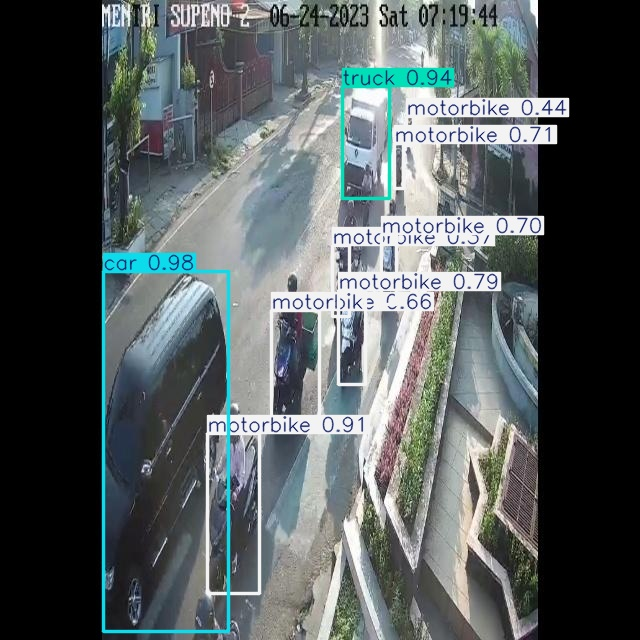

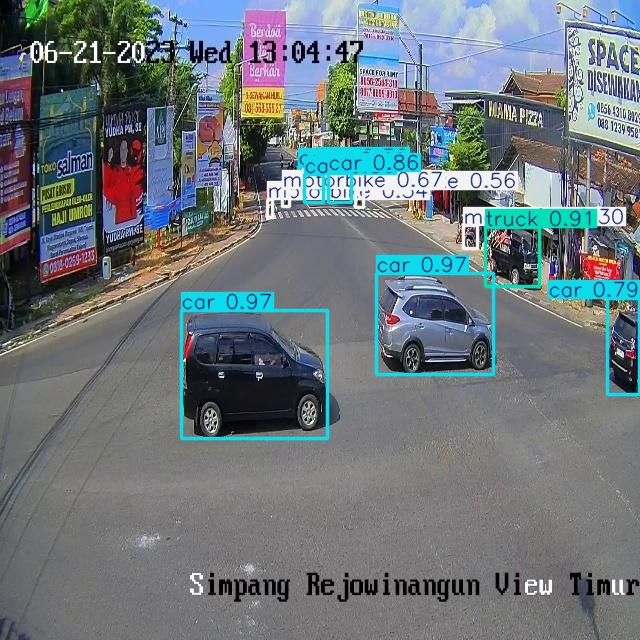

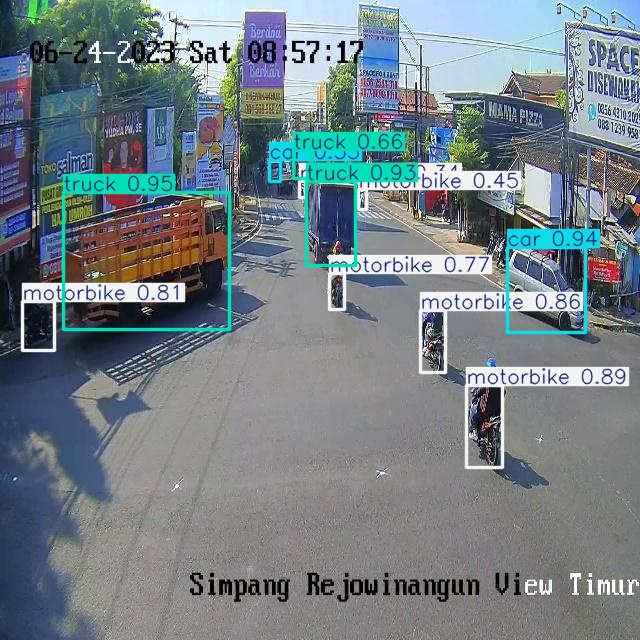

In [ ]:
from IPython.display import Image, display
import glob

output_images = glob.glob('/content/runs/detect/vehicle_detection/inference/*.jpg')[:3]

for img_path in output_images:
    display(Image(filename=img_path, width=640))

In [ ]:
from google.colab import files

files.download(output_images[1])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/runs/detect/vehicle_detection/run1-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>